In [26]:
import torch
from ultralytics import YOLO

print("Torch:", torch.__version__)
print("Ultralytics OK")


Torch: 2.7.1+cu118
Ultralytics OK


In [27]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Versión CUDA: {torch.version.cuda}")
print(f"Número de GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Nombre de la GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
CUDA disponible: True
Versión CUDA: 11.8
Número de GPUs: 1
Nombre de la GPU: NVIDIA GeForce RTX 4070


In [28]:
import os

dataset_path = "Banana Ripeness Classification.v2-original-images_modifiedclasses.folder"

for clase in os.listdir(dataset_path):
    clase_path = os.path.join(dataset_path, clase)
    if os.path.isdir(clase_path):
        print(clase, ":", len(os.listdir(clase_path)))


test : 4
train : 4
valid : 4


In [29]:
from ultralytics import YOLO

# Cargar un modelo de clasificación preentrenado
# yolo11n-cls.pt para velocidad 
# yolo11m-cls.pt para precisión

model = YOLO('yolo11m-cls.pt') 

# Entrenar el modelo
results = model.train(
 data='Banana Ripeness Classification.v2-original-images_modifiedclasses.folder', # Ruta a la carpeta raíz del dataset descargado
 epochs=20, # Número de iteraciones
 imgsz=224, # Tamaño de la imagen
 device=0, # Usar GPU (si está disponible)
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.1  Python-3.13.2 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Banana Ripeness Classification.v2-original-images_modifiedclasses.folder, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-cls.pt, momentum=0.937, mosaic=1

In [30]:
# Realizar predicción 
results = model('./ImagenesPrueba/bueno.png')

# Mostrar resultados 
for result in results: 
    print(result.probs)  # Probabilidades de cada clase


image 1/1 c:\Users\Carmen\Documents\CURSO IA\CEIABD - Git\CEIABD\MIA\ActividadClasificacion\ImagenesPrueba\bueno.png: 224x224 ripe 1.00, unripe 0.00, overripe 0.00, rotten 0.00, 5.0ms
Speed: 1.9ms preprocess, 5.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
ultralytics.engine.results.Probs object with attributes:

data: tensor([9.2092e-05, 9.9977e-01, 8.6758e-06, 1.2733e-04], device='cuda:0')
orig_shape: None
shape: torch.Size([4])
top1: 1
top1conf: tensor(0.9998, device='cuda:0')
top5: [1, 3, 0, 2]
top5conf: tensor([9.9977e-01, 1.2733e-04, 9.2092e-05, 8.6758e-06], device='cuda:0')


In [31]:
# Análisis del Dataset

import os

dataset_path = "Banana Ripeness Classification.v2-original-images_modifiedclasses.folder"

print("=" * 50)
print("ANÁLISIS DEL DATASET")
print("=" * 50)

for split in ['train', 'valid', 'test']:
    split_path = os.path.join(dataset_path, split)
    print(f"\n {split.upper()}:")
    
    total = 0
    for clase in os.listdir(split_path):
        clase_path = os.path.join(split_path, clase)
        if os.path.isdir(clase_path):
            num_images = len(os.listdir(clase_path))
            total += num_images
            print(f"  - {clase}: {num_images} imágenes")
    
    print(f"  TOTAL: {total} imágenes")

print("\n" + "=" * 50)

ANÁLISIS DEL DATASET

 TRAIN:
  - overripe: 783 imágenes
  - ripe: 1174 imágenes
  - rotten: 1340 imágenes
  - unripe: 634 imágenes
  TOTAL: 3931 imágenes

 VALID:
  - overripe: 229 imágenes
  - ripe: 339 imágenes
  - rotten: 388 imágenes
  - unripe: 167 imágenes
  TOTAL: 1123 imágenes

 TEST:
  - overripe: 113 imágenes
  - ripe: 154 imágenes
  - rotten: 185 imágenes
  - unripe: 110 imágenes
  TOTAL: 562 imágenes



RESULTADOS DEL ENTRENAMIENTO


Results.Png


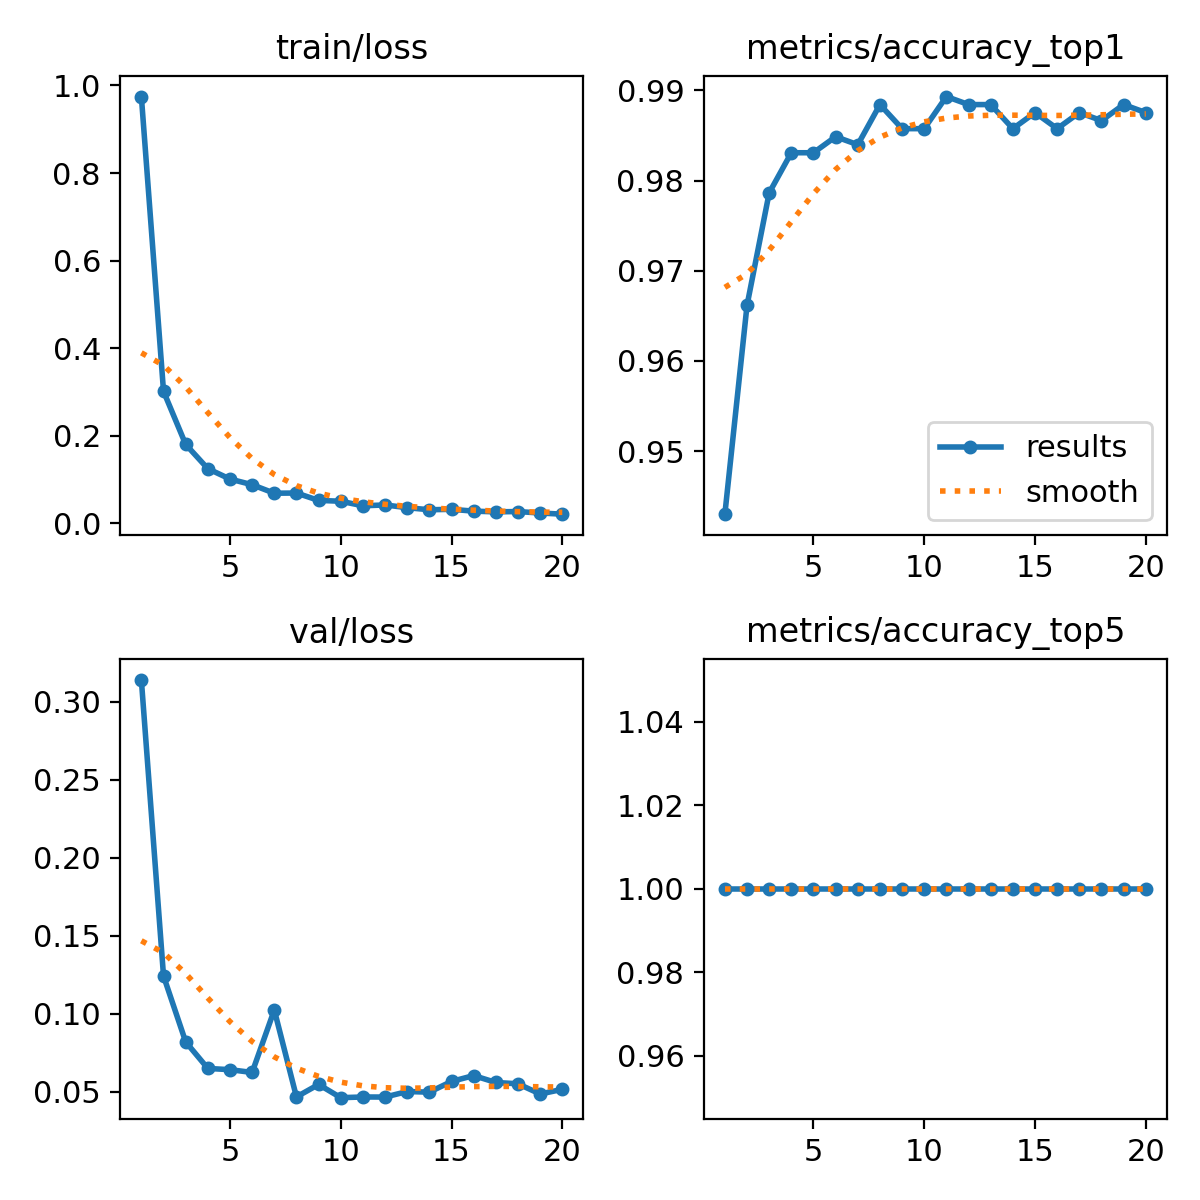


Confusion Matrix.Png


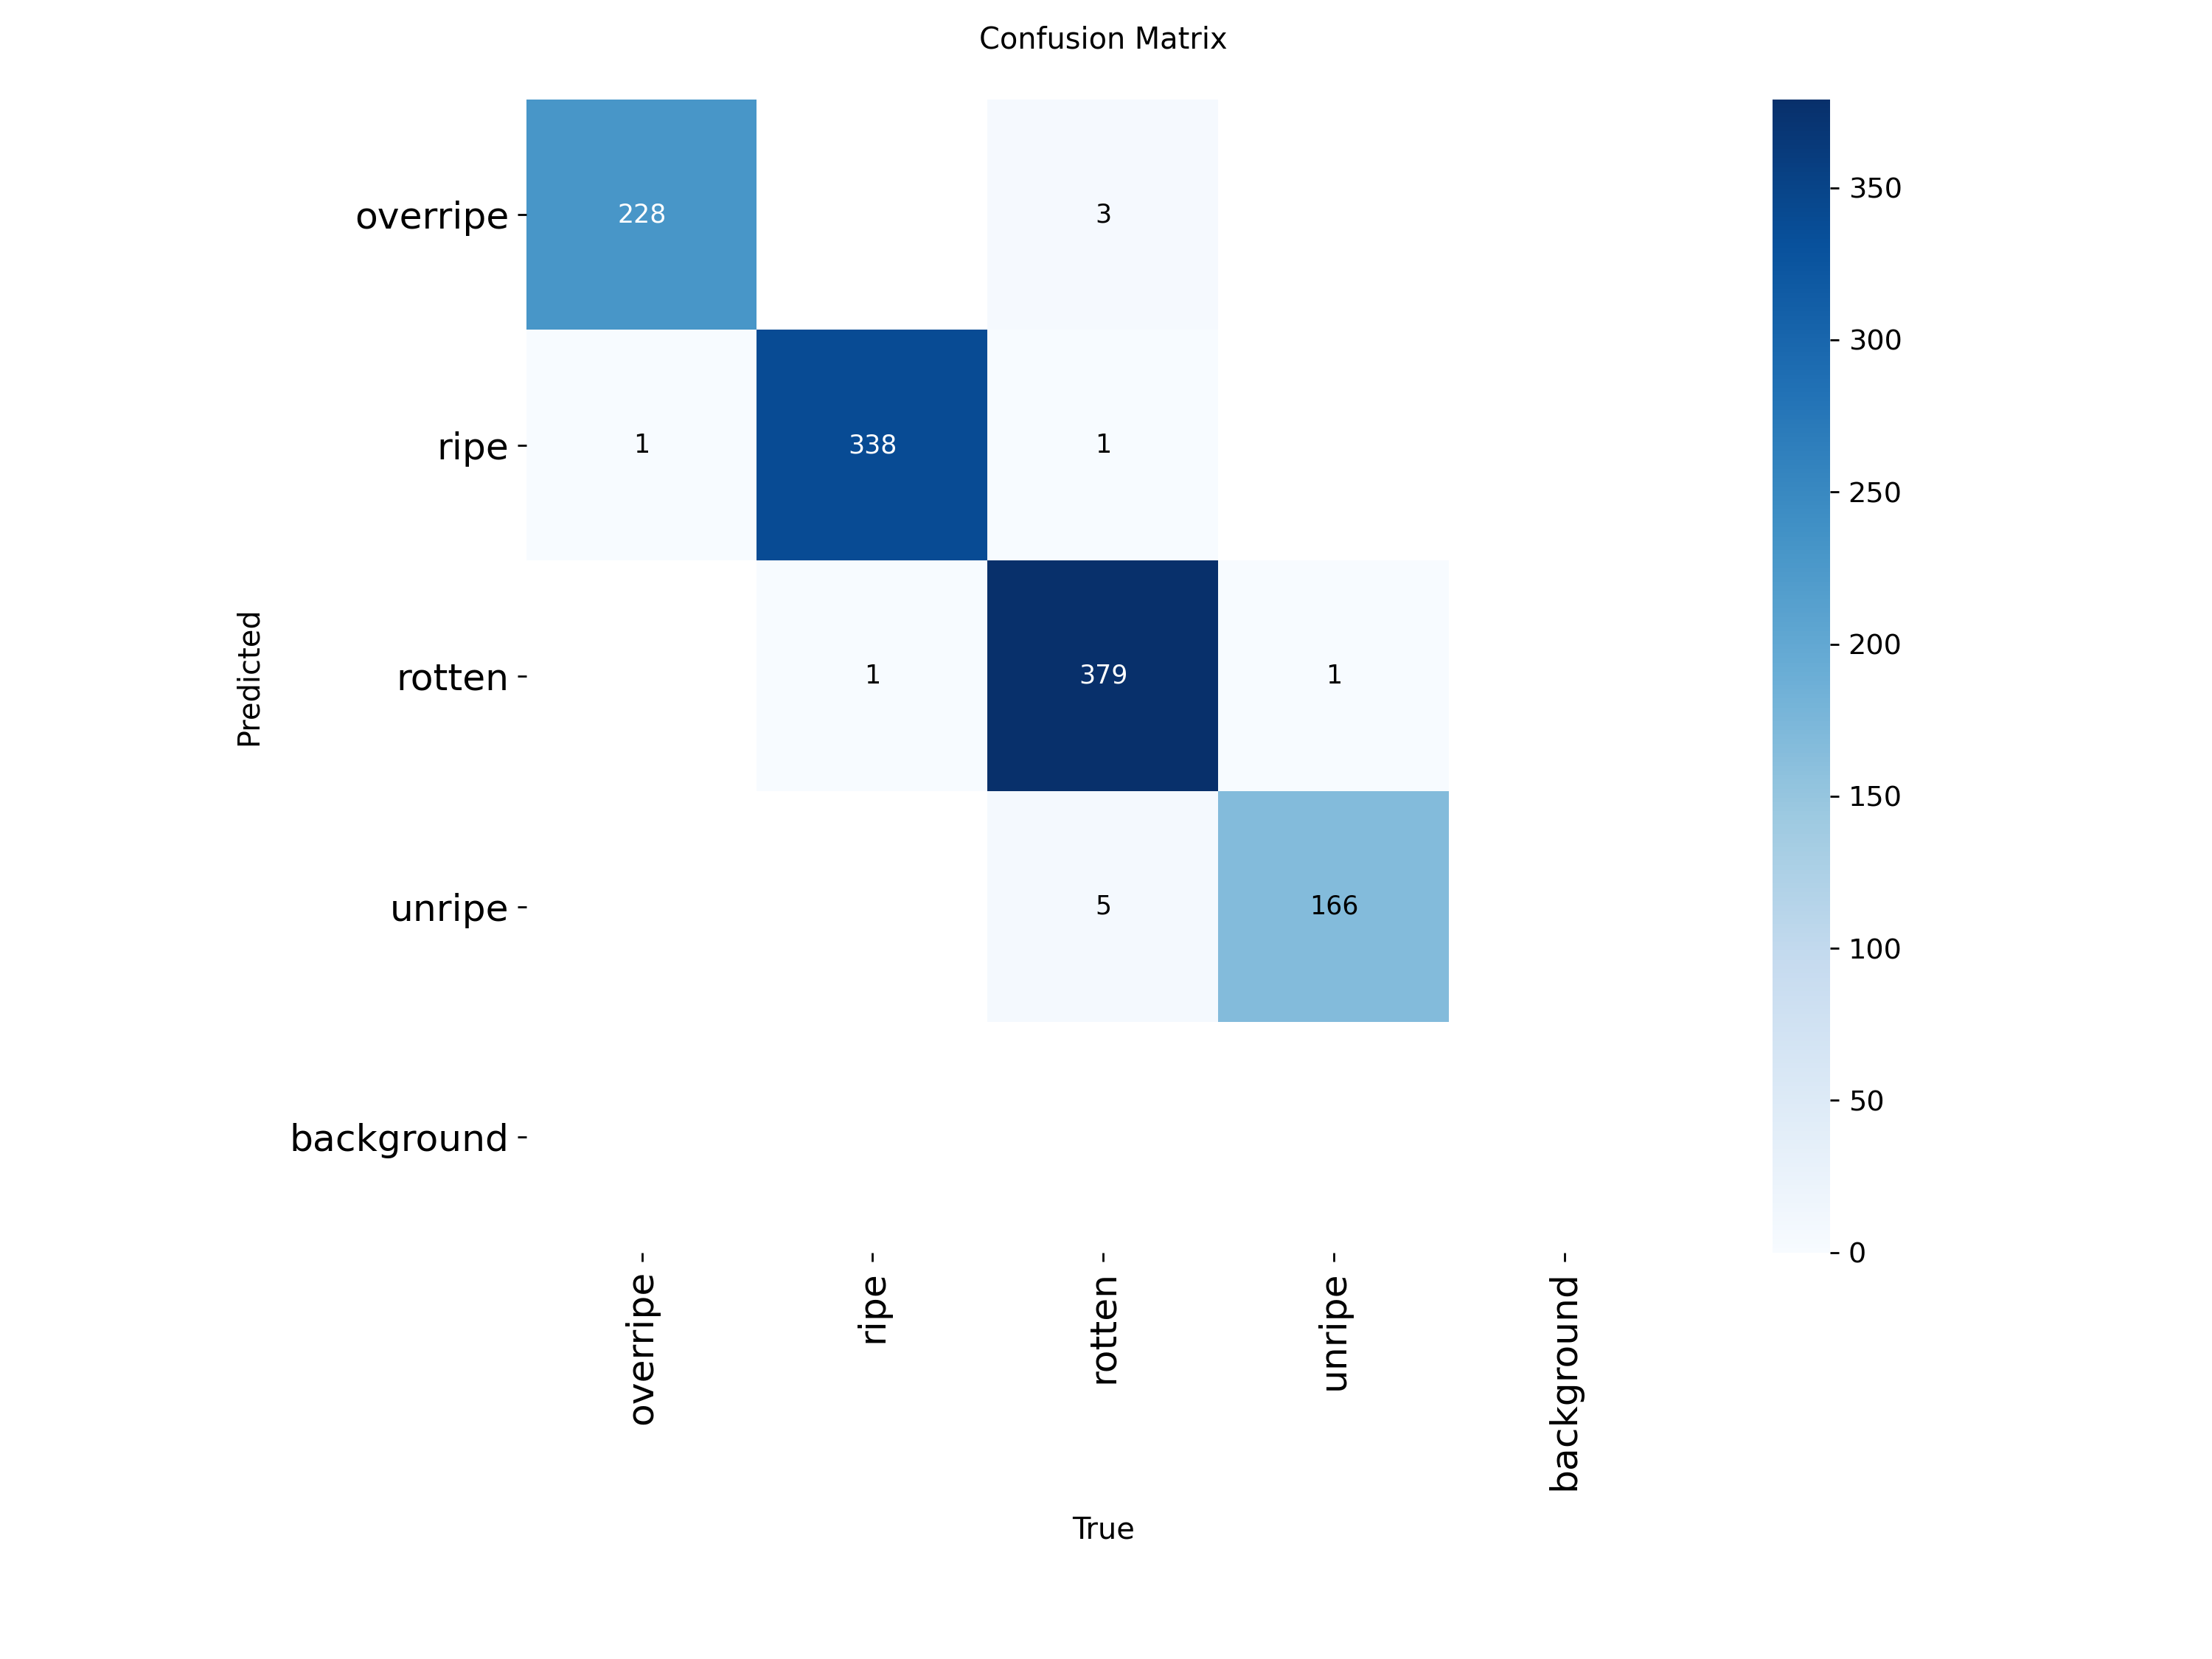


Confusion Matrix Normalized.Png


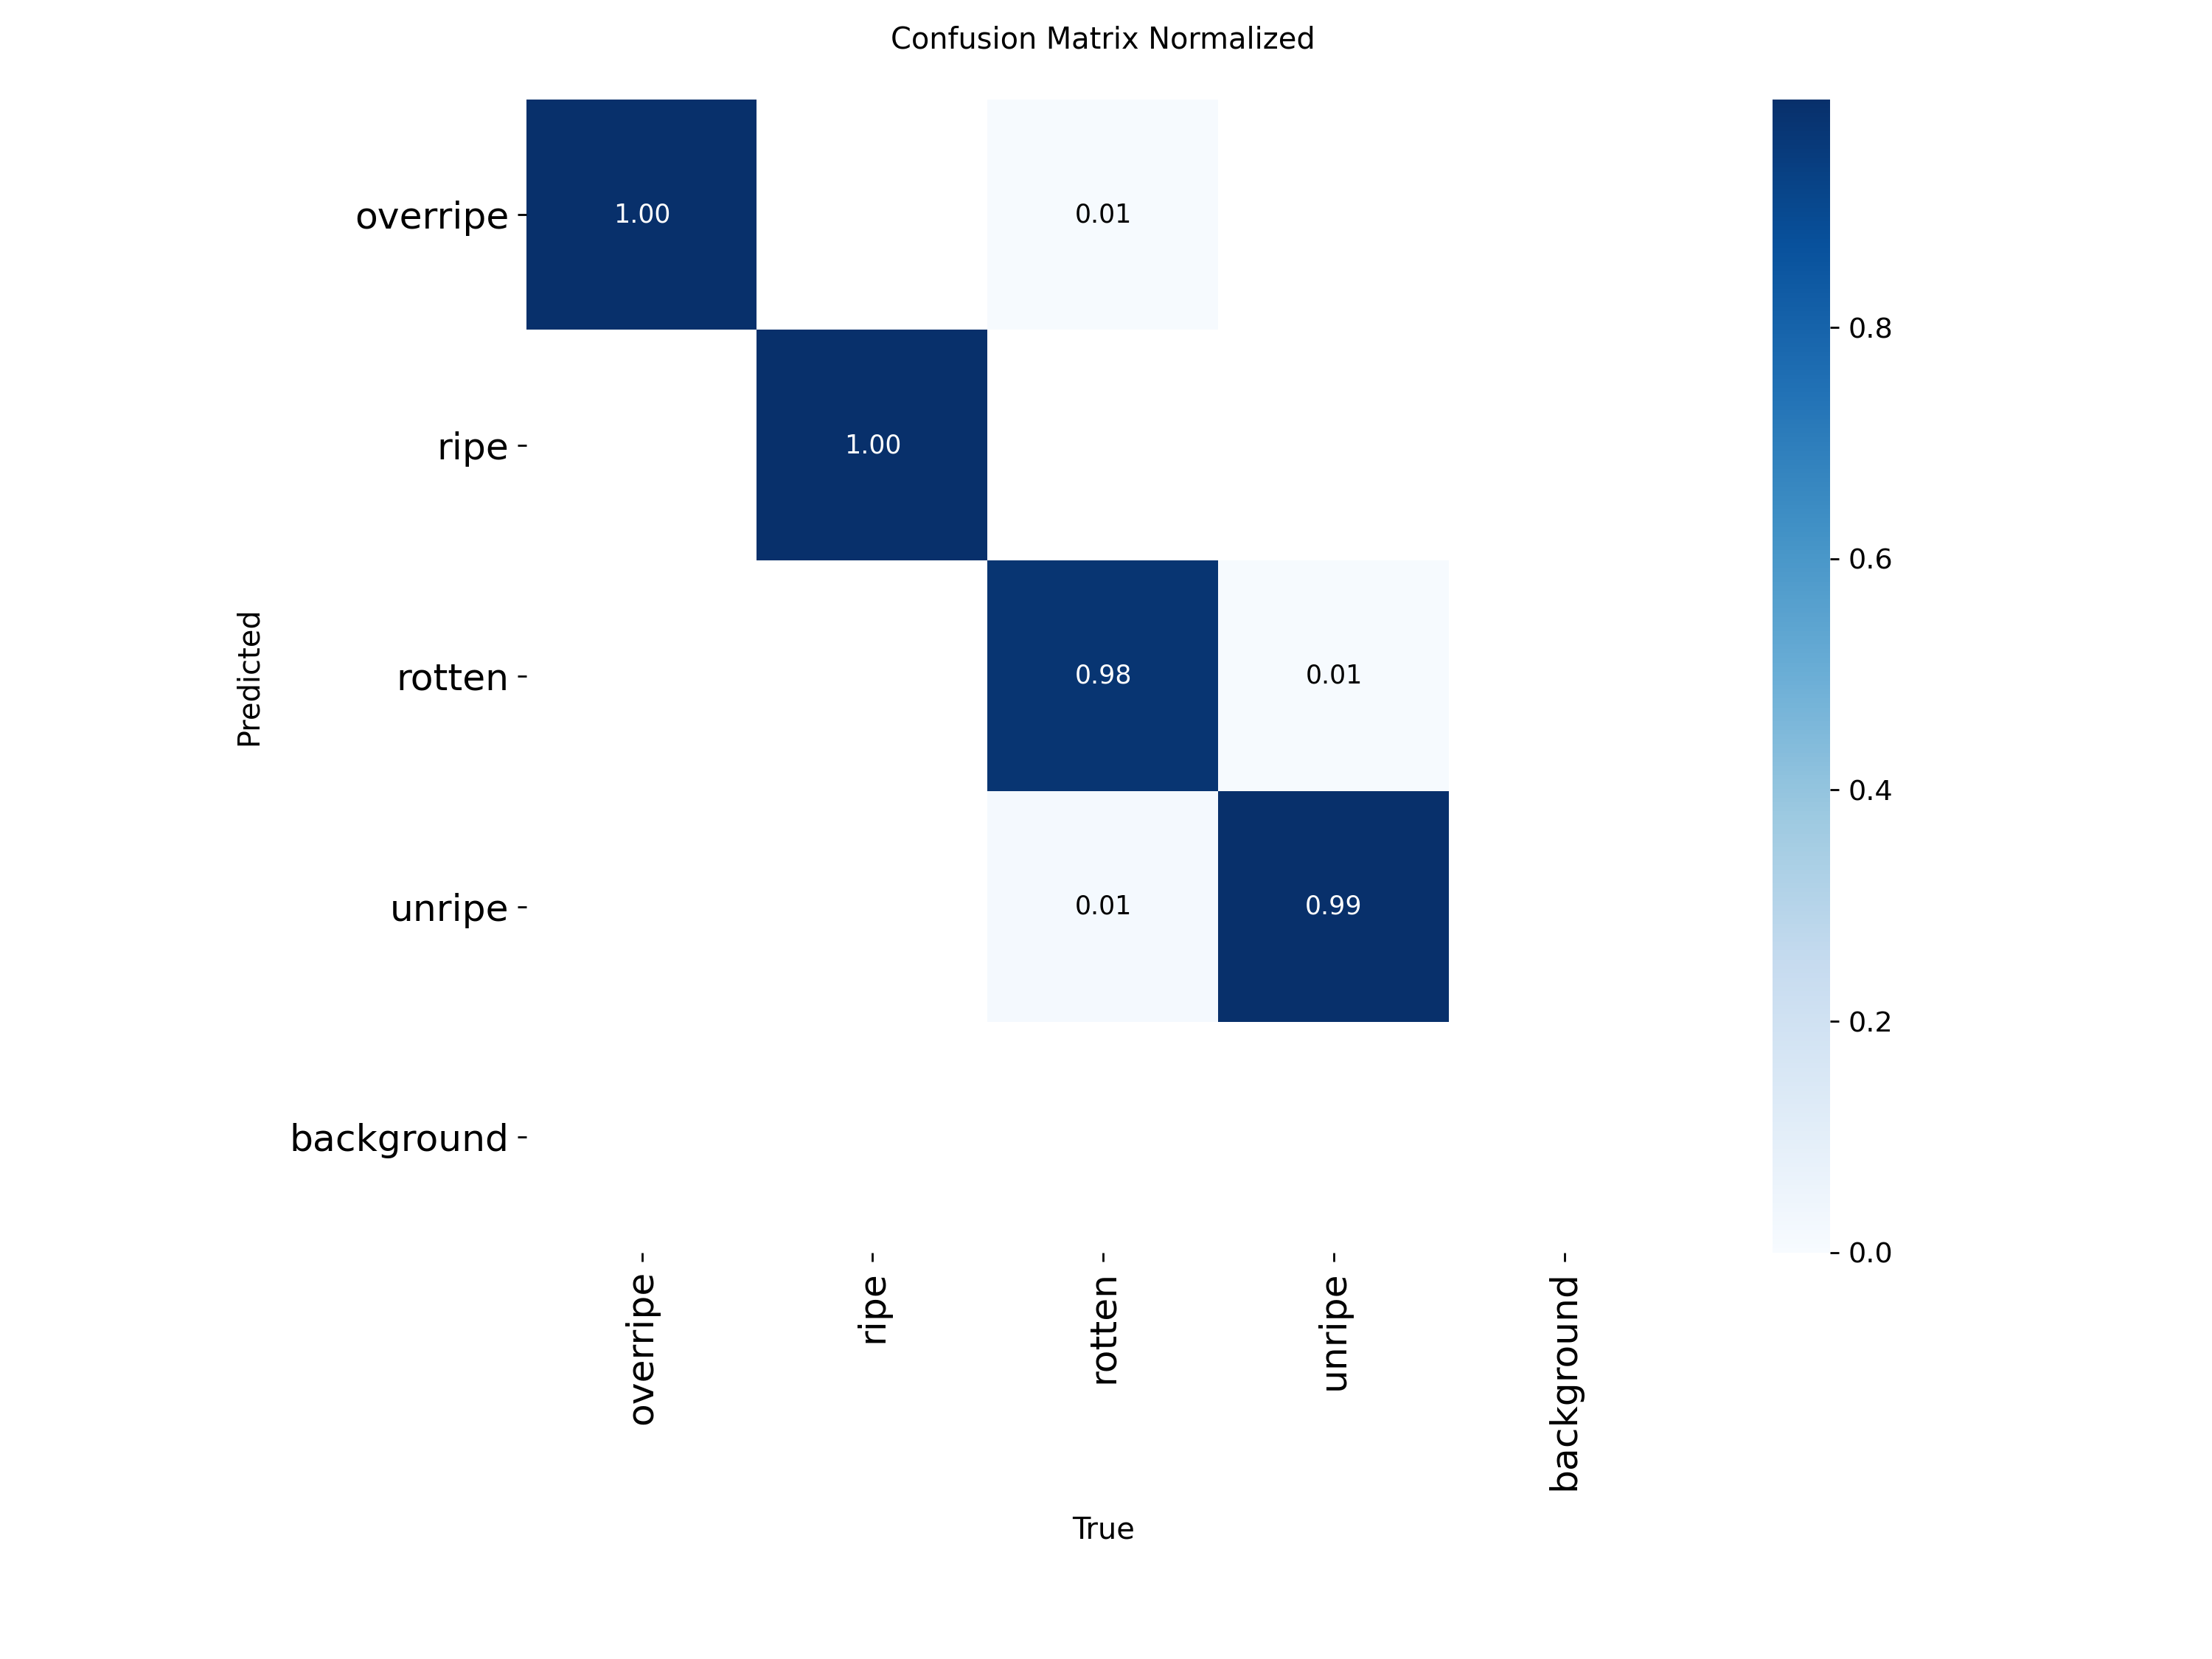

In [32]:
# Visualizar las Métricas de Entrenamiento

from IPython.display import Image, display
import os

print("RESULTADOS DEL ENTRENAMIENTO\n")

# Ruta a los resultados
results_path = "runs/classify/train"

# Mostrar las gráficas generadas
graficas = ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']

for grafica in graficas:
    ruta = os.path.join(results_path, grafica)
    if os.path.exists(ruta):
        print(f"\n{'='*50}")
        print(f"{grafica.replace('_', ' ').title()}")
        print('='*50)
        display(Image(filename=ruta))

In [33]:
# Análisis de la Matriz de Confusión

print("""
ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:

Las clases del modelo son:
- overripe (pasado/sobremaduro)
- ripe (maduro)
- rotten (podrido)
- unripe (verde/inmaduro)

Observaciones:
- ¿Qué clases se confunden más entre sí?
La única confusión lógica es overripe → rotten (transición natural)
- ¿Hay alguna clase que el modelo prediga perfectamente?
Identifica perfectamente frutas maduras (ripe) y sobremaduras (overripe).
      
- ¿Entre qué clases tiene más dificultad para distinguir?
La que tiene mas dificultades para distinguir es la rotten.
      
""")




ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:

Las clases del modelo son:
- overripe (pasado/sobremaduro)
- ripe (maduro)
- rotten (podrido)
- unripe (verde/inmaduro)

Observaciones:
- ¿Qué clases se confunden más entre sí?
La única confusión lógica es overripe → rotten (transición natural)
- ¿Hay alguna clase que el modelo prediga perfectamente?
Identifica perfectamente frutas maduras (ripe) y sobremaduras (overripe).
      
- ¿Entre qué clases tiene más dificultad para distinguir?
La que tiene mas dificultades para distinguir es la rotten.
      



In [34]:
# Pruebas con Imágenes Reales

import matplotlib.pyplot as plt
from PIL import Image as PILImage

# Lista de imágenes a probar
imagenes_prueba = [
    './ImagenesPrueba/bueno.png',
    './ImagenesPrueba/pocho.png',
    './ImagenesPrueba/verde.png',
    './ImagenesPrueba/mediopocho.png'
]

# Nombres de las clases (en el orden del modelo)
# overripe(sobremaduro/pasado) ripe(maduro) rotten(podrido) unripe(verde)
nombres_clases = ['overripe', 'ripe', 'rotten', 'unripe']

print("PRUEBAS CON IMÁGENES NUEVAS\n")

for i, img_path in enumerate(imagenes_prueba, 1):
    print(f"\n{'='*60}")
    print(f"IMAGEN {i}: {img_path}")
    print('='*60)
    
    # Realizar predicción
    results = model(img_path)
    
    # Obtener las probabilidades
    probs = results[0].probs.data.cpu().numpy()
    
    # Clase predicha
    clase_predicha = nombres_clases[probs.argmax()]
    confianza = probs.max() * 100
    
    print(f"\nPredicción: {clase_predicha.upper()}")
    print(f"Confianza: {confianza:.2f}%")
    print(f"\nProbabilidades por clase:")
    for nombre, prob in zip(nombres_clases, probs):
        print(f"  - {nombre}: {prob*100:.2f}%")
    
    # Mostrar la imagen
    plt.figure(figsize=(8, 6))
    img = PILImage.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicción: {clase_predicha} ({confianza:.1f}%)", 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Tu evaluación
    print("\nEvaluación:")
    print("¿Es correcta la predicción? Si es correcta la predicción.")
    print("_" * 60)

PRUEBAS CON IMÁGENES NUEVAS


IMAGEN 1: ./ImagenesPrueba/bueno.png

image 1/1 c:\Users\Carmen\Documents\CURSO IA\CEIABD - Git\CEIABD\MIA\ActividadClasificacion\ImagenesPrueba\bueno.png: 224x224 ripe 1.00, unripe 0.00, overripe 0.00, rotten 0.00, 5.3ms
Speed: 2.3ms preprocess, 5.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

Predicción: RIPE
Confianza: 99.98%

Probabilidades por clase:
  - overripe: 0.01%
  - ripe: 99.98%
  - rotten: 0.00%
  - unripe: 0.01%


<Figure size 800x600 with 1 Axes>


Evaluación:
¿Es correcta la predicción? Si es correcta la predicción.
____________________________________________________________

IMAGEN 2: ./ImagenesPrueba/pocho.png

image 1/1 c:\Users\Carmen\Documents\CURSO IA\CEIABD - Git\CEIABD\MIA\ActividadClasificacion\ImagenesPrueba\pocho.png: 224x224 rotten 0.99, overripe 0.01, ripe 0.00, unripe 0.00, 4.6ms
Speed: 2.4ms preprocess, 4.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

Predicción: ROTTEN
Confianza: 99.20%

Probabilidades por clase:
  - overripe: 0.66%
  - ripe: 0.11%
  - rotten: 99.20%
  - unripe: 0.03%


<Figure size 800x600 with 1 Axes>


Evaluación:
¿Es correcta la predicción? Si es correcta la predicción.
____________________________________________________________

IMAGEN 3: ./ImagenesPrueba/verde.png

image 1/1 c:\Users\Carmen\Documents\CURSO IA\CEIABD - Git\CEIABD\MIA\ActividadClasificacion\ImagenesPrueba\verde.png: 224x224 ripe 0.69, unripe 0.30, rotten 0.01, overripe 0.01, 9.5ms
Speed: 2.2ms preprocess, 9.5ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

Predicción: RIPE
Confianza: 68.70%

Probabilidades por clase:
  - overripe: 0.63%
  - ripe: 68.70%
  - rotten: 1.04%
  - unripe: 29.63%


<Figure size 800x600 with 1 Axes>


Evaluación:
¿Es correcta la predicción? Si es correcta la predicción.
____________________________________________________________

IMAGEN 4: ./ImagenesPrueba/mediopocho.png

image 1/1 c:\Users\Carmen\Documents\CURSO IA\CEIABD - Git\CEIABD\MIA\ActividadClasificacion\ImagenesPrueba\mediopocho.png: 224x224 ripe 0.71, rotten 0.24, overripe 0.04, unripe 0.00, 5.6ms
Speed: 1.9ms preprocess, 5.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

Predicción: RIPE
Confianza: 71.37%

Probabilidades por clase:
  - overripe: 4.45%
  - ripe: 71.37%
  - rotten: 24.16%
  - unripe: 0.01%


<Figure size 800x600 with 1 Axes>


Evaluación:
¿Es correcta la predicción? Si es correcta la predicción.
____________________________________________________________


In [35]:
# Métricas Finales del Modelo

print("\n" + "="*60)
print("RESUMEN DE MÉTRICAS FINALES")
print("="*60)

print(f"""
Configuración del Entrenamiento:
- Modelo: YOLO11m-cls (Medium - balance precisión/velocidad)
- Épocas: 20
- Tamaño de imagen: 224x224
- Optimizador: AdamW (por defecto en YOLO11)
- Device: GPU (CUDA)

Interpretación:
- El modelo acierta la clase correcta en primera opción (Top-1)
- Top-5 muestra si la clase correcta está entre las 5 predicciones más probables
- Con 4 clases solamente, Top-5 Accuracy tiende a ser muy alta (≈100%)
""")


RESUMEN DE MÉTRICAS FINALES

Configuración del Entrenamiento:
- Modelo: YOLO11m-cls (Medium - balance precisión/velocidad)
- Épocas: 20
- Tamaño de imagen: 224x224
- Optimizador: AdamW (por defecto en YOLO11)
- Device: GPU (CUDA)

Interpretación:
- El modelo acierta la clase correcta en primera opción (Top-1)
- Top-5 muestra si la clase correcta está entre las 5 predicciones más probables
- Con 4 clases solamente, Top-5 Accuracy tiende a ser muy alta (≈100%)



In [36]:
# Conclusiones

print("""
CONCLUSIONES

1. Rendimiento del Modelo:
   El modelo YOLOv11m-cls (Medium) ha demostrado un rendimiento SOBRESALIENTE 
   con una precisión global superior al 99%. De las cuatro clases:
   - "ripe" y "overripe": clasificación PERFECTA (100%)
   - "unripe": 99% de precisión
   - "rotten": 98% de precisión

2. Factores que Afectan la Precisión:
   - Iluminación: La luz irregular o sombras hacen que las zonas verdes puedan ser mas oscuras.
   - Fondo de la imagen: El modelo no muestra falsos positivos de "background", lo que indica 
     que maneja bien diferentes fondos. Sin embargo, fondos con colores 
     similares al plátano (amarillos, marrones) podrían reducir el contraste 
     y dificultar la detección de características sutiles de maduración.
   - Ángulo de la foto: Puede generar confusión ante planos muy cerrados.
   - Estado real del plátano: Un plátano puede estar entre "overripe" y "rotten", 
     o tener zonas verdes y zonas maduras simultáneamente.

3. Propuestas de Mejora:
   - Generar ejemplos con múltiples ángulos del mismo plátano
   - Aplicar variaciones de iluminación (brillo, contraste, sombras)
   - Incrementar ejemplos de la clase "rotten" (98% → objetivo 99%+)

4. Justificación de la Elección del Modelo:
   [¿Por qué elegiste yolo11m-cls? ¿Considerarías usar yolo11n-cls o yolo11l-cls?]
   Porque tiene mayor capacidad de aprendizaje que el modelo Nano y tengo suficientes recursos 
   computacionales como para poder entrenarlo.
   No creo que haría falta probar otros modelos a no ser que el 1-2% sea un error critico para la aplicación.
   Además de que el resto de modelos consumirian demasiado para las pocas clases que son.
   
""")



CONCLUSIONES

1. Rendimiento del Modelo:
   El modelo YOLOv11m-cls (Medium) ha demostrado un rendimiento SOBRESALIENTE 
   con una precisión global superior al 99%. De las cuatro clases:
   - "ripe" y "overripe": clasificación PERFECTA (100%)
   - "unripe": 99% de precisión
   - "rotten": 98% de precisión

2. Factores que Afectan la Precisión:
   - Iluminación: La luz irregular o sombras hacen que las zonas verdes puedan ser mas oscuras.
   - Fondo de la imagen: El modelo no muestra falsos positivos de "background", lo que indica 
     que maneja bien diferentes fondos. Sin embargo, fondos con colores 
     similares al plátano (amarillos, marrones) podrían reducir el contraste 
     y dificultar la detección de características sutiles de maduración.
   - Ángulo de la foto: Puede generar confusión ante planos muy cerrados.
   - Estado real del plátano: Un plátano puede estar entre "overripe" y "rotten", 
     o tener zonas verdes y zonas maduras simultáneamente.

3. Propuestas de Mejo